In [1]:
import h5py


In [2]:
data=h5py.File('outputtrajs/4000mddata2.h5',mode='r')

In [3]:
data.visit(print)


hoomd-data
hoomd-data/Simulation
hoomd-data/Simulation/timestep
hoomd-data/Simulation/walltime
hoomd-data/md
hoomd-data/md/compute
hoomd-data/md/compute/ThermodynamicQuantities
hoomd-data/md/compute/ThermodynamicQuantities/degrees_of_freedom
hoomd-data/md/compute/ThermodynamicQuantities/kinetic_energy
hoomd-data/md/compute/ThermodynamicQuantities/kinetic_temperature
hoomd-data/md/compute/ThermodynamicQuantities/num_particles
hoomd-data/md/compute/ThermodynamicQuantities/potential_energy
hoomd-data/md/compute/ThermodynamicQuantities/pressure
hoomd-data/md/compute/ThermodynamicQuantities/pressure_tensor
hoomd-data/md/compute/ThermodynamicQuantities/rotational_degrees_of_freedom
hoomd-data/md/compute/ThermodynamicQuantities/rotational_kinetic_energy
hoomd-data/md/compute/ThermodynamicQuantities/translational_degrees_of_freedom
hoomd-data/md/compute/ThermodynamicQuantities/translational_kinetic_energy
hoomd-data/md/compute/ThermodynamicQuantities/volume


In [4]:
ke=data['hoomd-data/md/compute/ThermodynamicQuantities/kinetic_energy'][:]
timestep=data['hoomd-data/Simulation/timestep'][:]
potential_energy=data['hoomd-data/md/compute/ThermodynamicQuantities/potential_energy'][:]
total_energy=ke+potential_energy

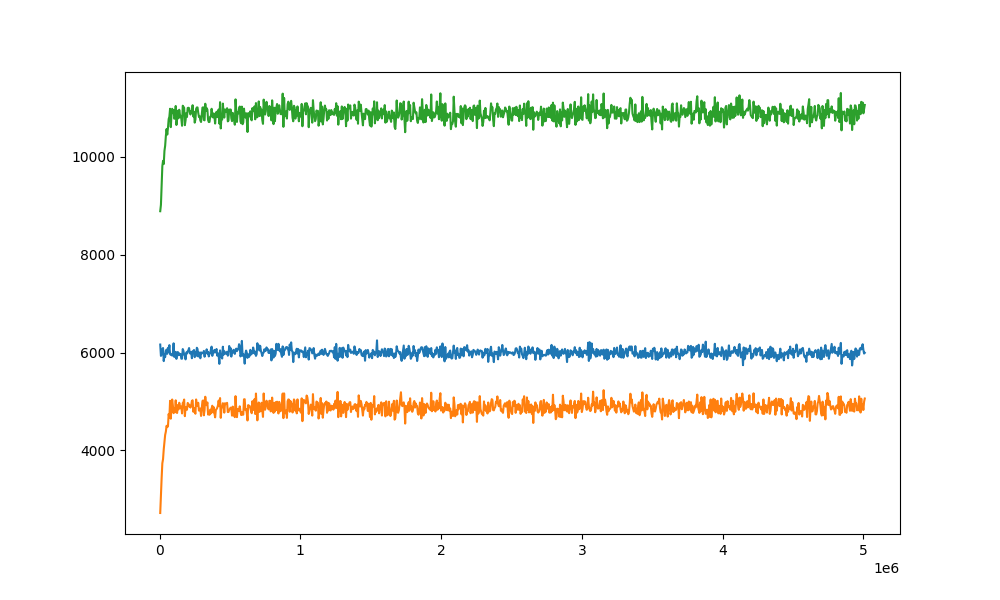

In [5]:
%matplotlib widget
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(timestep,ke)
plt.plot(timestep,potential_energy)
plt.plot(timestep,total_energy)



In [6]:
data.close()

In [51]:
from gsd.hoomd import *
file=open('A10soft_2k_8.50_fullring/run_0_2k_3.50_fullringrepsoft.gsd',mode='r')
len(file)

4991

In [2]:
%matplotlib widget
import gsd.hoomd
import numpy as np
import matplotlib.pyplot as plt

avg40=np.zeros(2000)
avg460=np.zeros(2000)
avg623=np.zeros(1752)
avg624=np.zeros(1752)
avgori1=np.zeros(2000)
avgori2=np.zeros(2000)

In [2]:
maxrun=30
for iter in range(0,maxrun):
    frames=gsd.hoomd.open(f'A10soft_20k_8.50_fullring_500_test_20krate/run_{iter}_20k_3.50_fullringrepsoft.gsd',mode='r')
    print(len(frames),iter)
    pos40=[]
    pos460=[]
    pos403=[]
    pos404=[]
    ori1=[]
    ori2=[]
    distori=[]
    framenum40=[]
    framenum403=[]
    i=0
    for frame in frames:
        N=frame.particles.N
        initN=500
        R=N-initN
        position=frame.particles.position
        # pos40.append(-position[40][2])
        # pos460.append(-position[460][2])
        ori1.append((position[0][2]))
        if(R>=1):
            ori2.append((position[500][2]))
        framenum40.append(i)

        # if(R>123):
            # pos403.append(position[403][2])
            # pos404.append(position[404][2])
            # framenum403.append(i)
        i=i+1
    # plt.figure(figsize=(10,8))
    # plt.plot(ori1,label='Ori1')
    # plt.plot(ori2,label='Ori2',color='r')
    # # plt.plot(framenum62,avg40,label='right1')
    # # plt.plot(framenum62,avg460,label='left1')
    # # plt.plot(framenum623,avg623,label='right2')
    # # plt.plot(framenum623,avg624,label='left2')
    # # plt.vlines(x=50000,ymin=-10.5,ymax=10.5,linestyles='dashed',label='Completion of replication',colors='blue')
    # plt.tick_params(axis='x', labelsize=15)  
    # plt.tick_params(axis='y', labelsize=15)
    # plt.xlabel(r'Simulation time [$\tau$]', fontsize=20,fontweight='bold')
    # plt.ylabel('Long axis position [a]', fontsize=20,fontweight='bold')
    # plt.title('Average trajectory',fontsize=20,fontweight='bold')
    # plt.grid(True)
    # for label in plt.gca().get_yticklabels():
    #     label.set_fontweight('bold')
    # for label in plt.gca().get_xticklabels():
    #     label.set_fontweight('bold')
    # plt.legend(fontsize=15)
    # avg40=avg40+np.array(pos40)
    # avg460=avg460+np.array(pos460)
    # avg403=np.array(avg403)+np.array(pos403)
    # avg404=np.array(avg404)+np.array(pos404)
    avgori1=np.array(avgori1)+np.array(ori1)
    avgori2=np.array(avgori2)+np.array(ori2)


2000 0
2000 1
2000 2
2000 3
2000 4
2000 5
2000 6
2000 7
2000 8
2000 9
2000 10
2000 11
2000 12
2000 13
2000 14
2000 15
2000 16
2000 17
2000 18
2000 19
2000 20
2000 21
2000 22
2000 23
2000 24
2000 25
2000 26
2000 27
2000 28
2000 29


In [3]:
maxrun=30
avgori1=avgori1/maxrun
avgori2=avgori2/maxrun
ori1framenum=np.array(framenum40)
ori2framenum=np.array(framenum40)
ori1time=ori1framenum*50
ori2time=ori2framenum*50

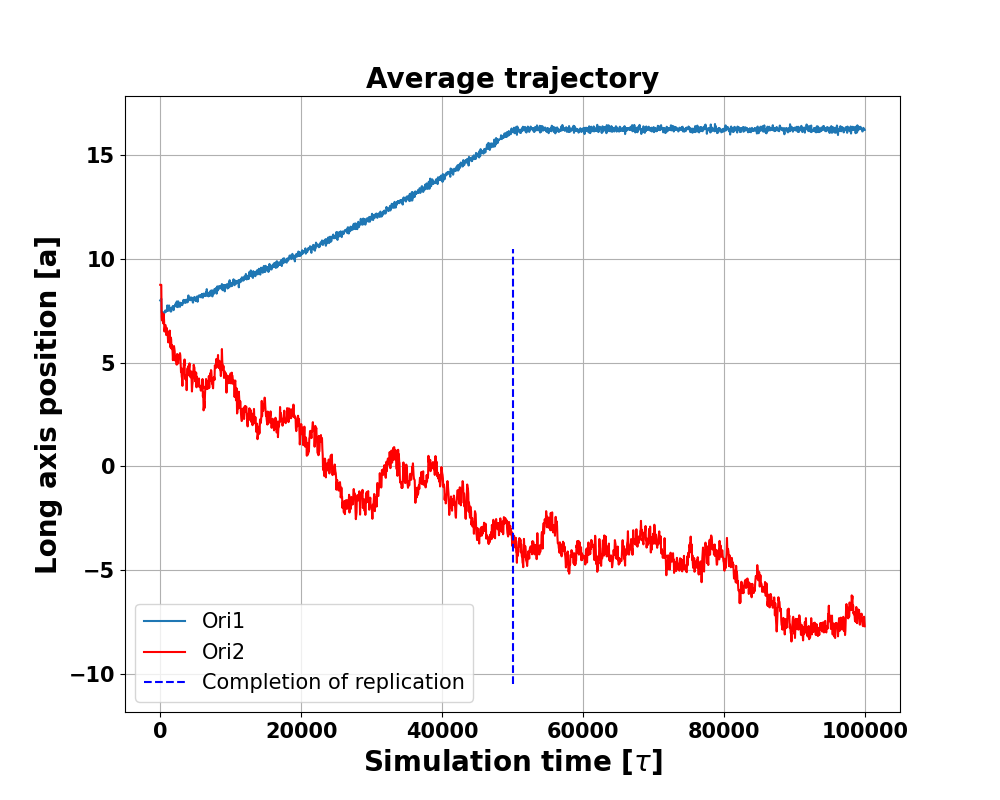

In [4]:
plt.figure(figsize=(10,8))
plt.plot(ori1time,avgori1,label='Ori1')
plt.plot(ori2time,avgori2,label='Ori2',color='r')
# plt.plot(framenum62,avg40,label='right1')
# plt.plot(framenum62,avg460,label='left1')
# plt.plot(framenum623,avg623,label='right2')
# plt.plot(framenum623,avg624,label='left2')
plt.vlines(x=50000,ymin=-10.5,ymax=10.5,linestyles='dashed',label='Completion of replication',colors='blue')
plt.tick_params(axis='x', labelsize=15)  
plt.tick_params(axis='y', labelsize=15)
plt.xlabel(r'Simulation time [$\tau$]', fontsize=20,fontweight='bold')
plt.ylabel('Long axis position [a]', fontsize=20,fontweight='bold')
plt.title('Average trajectory',fontsize=20,fontweight='bold')
plt.grid(True)
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
plt.legend(fontsize=15)
# plt.savefig('Myplots/Oritraj.png',dpi=400)

In [3]:
%matplotlib widget
import gsd.hoomd
import numpy as np
import matplotlib.pyplot as plt





In [26]:
maxiter=13
startiter=0
L=28
initparticle=500
avgdist=np.zeros(1200)
avgori1=np.zeros(1200)
avgori2=np.zeros(1200)
timefile=np.zeros(1200)
numiter=[0,4,5,6,7,8,9,10,11,13,14,17,20,21,23,26,29]
for iter in range(startiter,maxiter):
# for iter in numiter:
    ori1=[]
    ori2=[]
    oridist=[]
    data=gsd.hoomd.open(f'A10soft_20k_8.50_fullring_1000_50_28_4_10krate_exp_assym/run_{iter}_20k_3.50_fullringrepsoft.gsd',mode='r')
    i=0
    for frame in data[:1200]:
        
        # print(ori1)
        if iter==startiter:
            timefile[i]=i*50/50/1000
            # print(i)
        R=frame.particles.N
        time=int(int(i/4)-1)
        lenth=L
        if time>=0 and time<=(initparticle/2):
            k = (np.log(2*L) - np.log(L)) / (initparticle/2)
            lenth=L*np.exp(k*time)
        if time>initparticle/2:
            lenth=2*L
        ori1.append(frame.particles.position[0][2])
        # lenth=L
        if R>501:
            ori2.append(frame.particles.position[500][2])
            oridist.append((frame.particles.position[0][2]-frame.particles.position[500][2])/lenth)
        else:
            ori2.append(frame.particles.position[0][2])
            oridist.append(0)
        i=i+1
    avgdist=avgdist+np.array(oridist)
    avgori1=avgori1+np.array(ori1)
    avgori2=avgori2+np.array(ori2)
    print(iter)
    # plt.figure(figsize=(10,6))
    # # plt.plot(timefile,avgori1,'*',label='Ori1')
    # # plt.plot(timefile,avgori2,'+',label='Ori2')
    # plt.plot(timefile,oridist,'.-',label='Avgdist')
    # plt.title(f'Run:{iter}')
    # plt.vlines(x=50000,ymin=0,ymax=1,linestyles='--',label='Replication time')
    # plt.legend()
    # plt.grid(True)



        



0
1
2
3
4
5
6
7
8
9
10
11
12


In [27]:
# maxiter=30
# startiter=1
L=28
initparticle=500
avgdist_1=np.zeros(1200)
avgori_1=np.zeros(1200)
avgori_2=np.zeros(1200)
timefile=np.zeros(1200)
numiter=[0,4,5,6,7,8,9,10,11,13,14,17,20,21,23,26,29]
for iter in range(startiter,maxiter):
# for iter in numiter:
    ori1=[]
    ori2=[]
    oridist=[]
    data=gsd.hoomd.open(f'A10soft_10k_8.50_fullring_1000_50_28_4_5krate_exp_assym_new1/run_{iter}_10k_3.50_fullringrepsoft.gsd',mode='r')
    i=0
    for frame in data:
        
        # print(ori1)
        if iter==startiter:
            timefile[i]=i*50/50/1000
            # print(i)
        R=frame.particles.N
        time=int(int(i/4)-1)
        lenth=L
        if time>=0 and time<=(initparticle/2):
            k = (np.log(2*L) - np.log(L)) / (initparticle/2)
            lenth=L*np.exp(k*time)
        if time>initparticle/2:
            lenth=2*L
        ori1.append(frame.particles.position[0][2])
        # lenth=L
        if R>501:
            ori2.append(frame.particles.position[500][2])
            oridist.append((frame.particles.position[0][2]-frame.particles.position[500][2])/lenth)
        else:
            ori2.append(frame.particles.position[0][2])
            oridist.append(0)
        i=i+1
    avgdist_1=avgdist_1+np.array(oridist)
    avgori_1=avgori_1+np.array(ori1)
    avgori_2=avgori_2+np.array(ori2)
    print(iter)
    # plt.figure(figsize=(10,6))
    # # plt.plot(timefile,avgori_1,'*',label='Ori1')
    # # plt.plot(timefile,avgori_2,'+',label='Ori2')
    # plt.plot(timefile,oridist,'.-',label='Avgdist_1')
    # plt.title(f'Run:{iter}')
    # plt.vlines(x=50000,ymin=0,ymax=1,linestyles='--',label='Replication time')
    # plt.legend()
    # plt.grid(True)



        



0
1
2
3
4
5
6
7
8
9
10
11
12


In [28]:
avgori1=avgori1/(maxiter-startiter)
avgori2=avgori2/(maxiter-startiter)
avgdist=avgdist/(maxiter-startiter)
avgori_1=avgori_1/(maxiter-startiter)
avgori_2=avgori_2/(maxiter-startiter)
avgdist_1=avgdist_1/(maxiter-startiter)
# avgori1=avgori1/len(numiter)
# avgori2=avgori2/len(numiter)
# avgdist=avgdist/len(numiter)

Text(0, 0.5, '$\\Delta _ Z\\ / \\ L_{\\mathrm{cyl}}$')

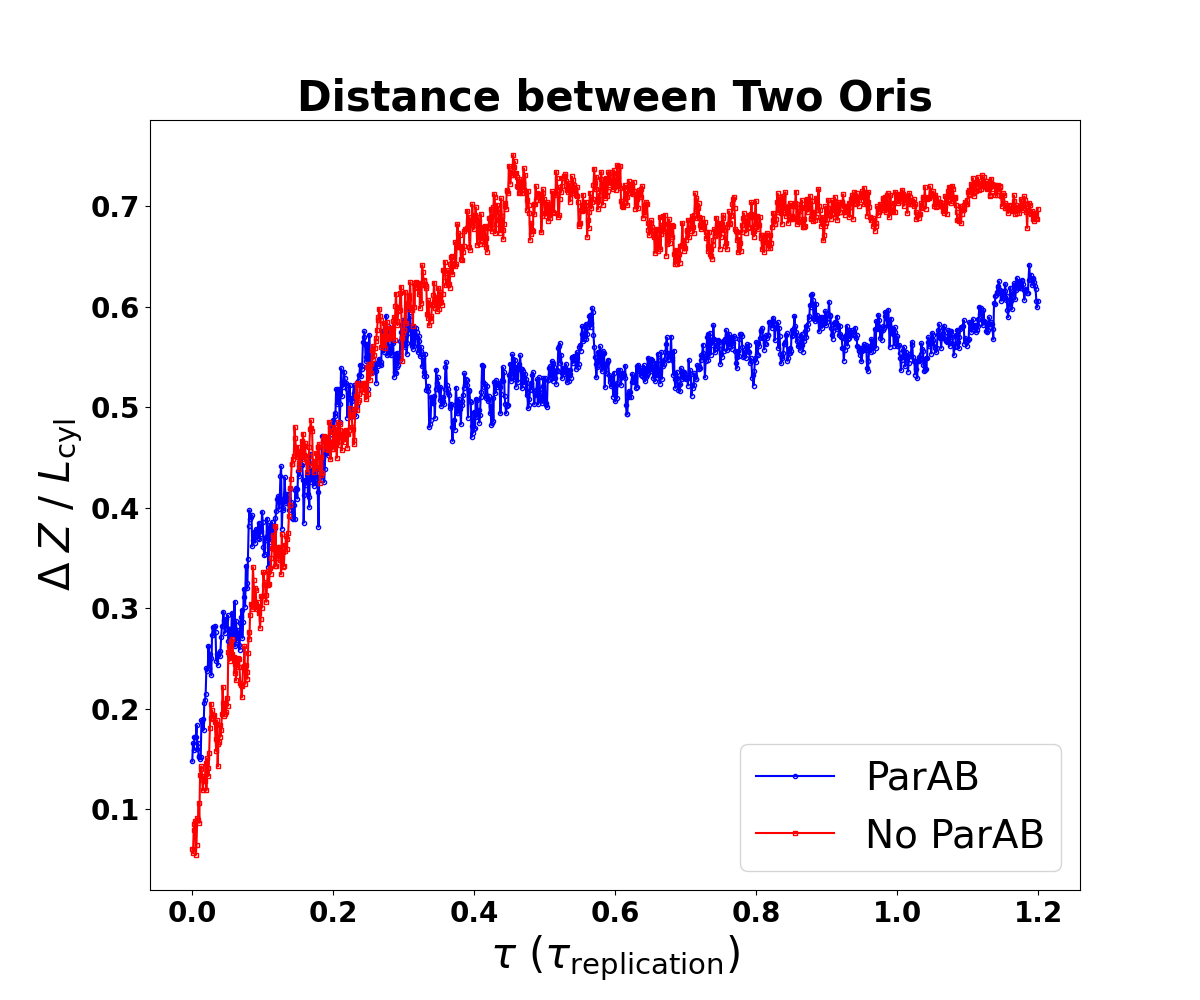

In [29]:
plt.figure(figsize=(12,10))
# plt.plot(timefile,avgori1,'*',label='Ori1')
# plt.plot(timefile,avgori2,'+',label='Ori2')
plt.plot(timefile,avgdist,label='ParAB',markersize='3',marker='o',markerfacecolor='none',color='blue')
plt.plot(timefile,avgdist_1,label='No ParAB',markersize='3',marker='s',markerfacecolor='none',color='red')
# plt.yscale('log')

plt.legend(fontsize=28)
plt.title(f'Distance between Two Oris',fontweight='bold',fontsize=30)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold') 
for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold') 
plt.xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$', fontsize=30, fontweight='bold')
plt.ylabel(r'$\Delta _ Z\ / \ L_{\mathrm{cyl}}$', fontsize=30, fontweight='bold')



# plt.grid(True)
# plt.savefig('Ori_dist_Ccrescentus.png',dpi=400)

In [62]:


plt.title(f'Distance between Two Ori of Daughter DNA',fontweight='bold',fontsize=22)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)
plt.xlabel(r'$ T (\tau_{replication})$',fontsize=22, fontweight='bold')
plt.ylabel(r'$\Delta _ Z / L_{{cylinder}}$',fontsize=22, fontweight='bold')
plt.legend(fontsize=22, frameon=True, fancybox=True, loc='best', title_fontsize=20, prop={'weight': 'bold'})

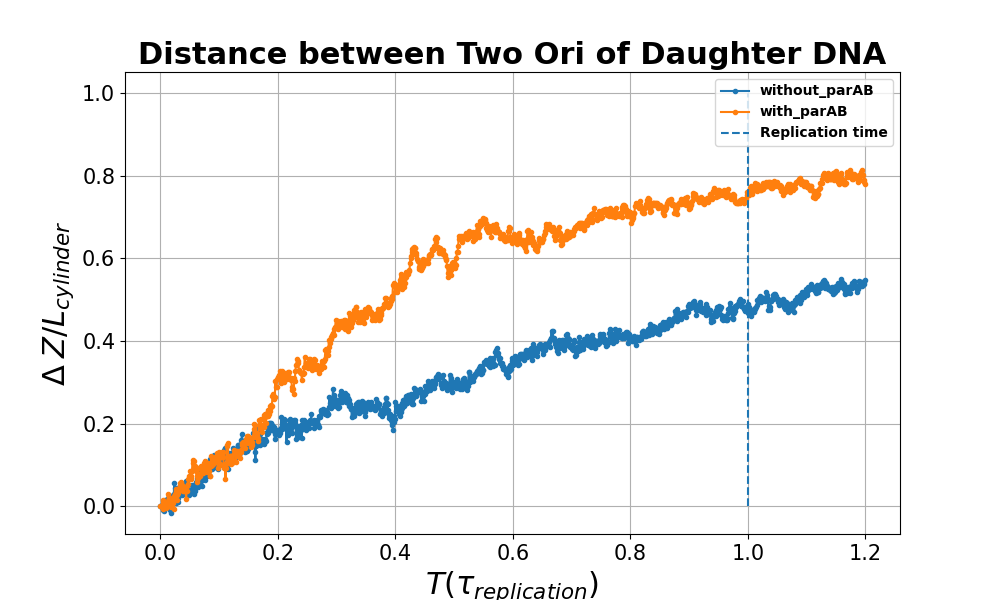

In [63]:

# plt.xscale('log')

plt.show()
# plt.close()

Generating exponential distribution


In [160]:
def exp_dist(x,rho):
    norm=1/(rho*(1-np.exp(-8/rho)))
    func=norm*np.exp(-x/rho)
    return func

In [200]:
#applying metropolise 
acceped=[]

for i in range(10000):
    flag=True
    while flag==True:
        randint=np.random.randint(0,8)
        print (randint)
        k=exp_dist(randint,2.2)
        randcheck=np.random.random()
        if k > randcheck:
            acceped.append(randint)
            flag= False
        else:
            flag=True



1
4
3
3
4
3
7
4
4
6
6
1
5
4
7
3
2
2
3
3
3
7
4
4
4
4
0
3
0
4
4
0
5
5
1
5
3
0
0
4
6
3
5
0
7
5
4
7
7
4
7
5
0
0
7
0
1
5
5
3
6
7
4
1
4
7
1
6
7
5
0
1
6
2
4
7
0
0
7
7
6
6
7
4
5
7
0
0
3
0
3
2
0
7
7
1
7
0
0
6
3
5
4
4
4
2
2
3
3
7
2
7
2
0
1
4
0
2
7
2
4
0
0
5
0
7
0
1
3
7
6
3
7
5
5
6
7
3
3
6
1
1
2
1
2
5
5
6
5
2
7
7
0
7
3
2
1
1
2
1
0
2
5
3
7
1
6
5
0
4
2
3
2
0
1
7
1
4
4
0
6
4
5
0
1
0
5
6
6
7
7
3
4
2
6
1
4
6
5
5
0
4
4
7
0
6
3
0
3
7
2
5
0
0
6
7
6
0
2
6
4
2
3
5
4
5
3
0
5
6
6
7
4
5
7
7
7
6
5
6
3
5
7
7
1
2
3
1
4
6
4
3
1
7
7
7
4
6
6
2
5
0
3
3
0
6
6
3
4
5
3
0
1
1
7
2
0
4
3
4
2
3
7
3
0
4
1
3
5
7
5
6
5
3
5
5
0
1
2
7
4
1
6
6
5
5
7
2
0
7
5
7
2
2
3
0
4
5
7
5
0
2
0
3
2
4
5
7
2
7
5
0
5
6
5
1
3
1
1
4
1
1
2
6
1
1
3
0
2
7
3
3
6
0
2
2
1
0
2
6
0
6
6
5
1
3
3
6
1
2
3
2
2
3
0
0
1
5
1
4
7
4
4
5
4
2
0
2
0
4
2
5
6
6
1
0
1
5
7
1
3
0
1
4
0
6
1
1
7
2
3
3
3
5
7
4
5
3
4
0
2
7
6
7
1
1
3
6
5
5
1
0
7
0
3
2
2
6
2
3
6
7
0
3
5
0
5
4
6
0
6
6
0
3
0
7
2
5
5
6
2
4
7
5
2
2
3
4
5
5
3
0
0
0
3
6
7
0
5
7
2
1
3
4
4
4
2
2
0
5
5
7
6
0
4
4
5
5
3
4


(array([0.53928571, 0.33285714, 0.221     , 0.        , 0.13185714,
        0.08585714, 0.        , 0.05642857, 0.03928571, 0.022     ]),
 array([0. , 0.7, 1.4, 2.1, 2.8, 3.5, 4.2, 4.9, 5.6, 6.3, 7. ]),
 [<matplotlib.patches.Polygon at 0x7f7531a074f0>])

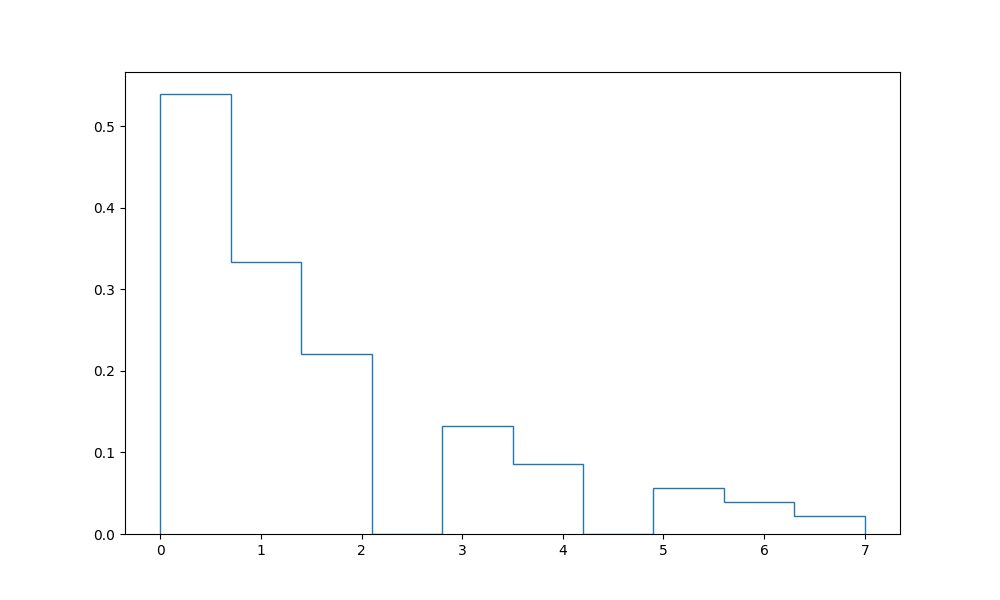

In [180]:
plt.figure(figsize=(10,6))
plt.hist(acceped,histtype='step',density=True)

In [199]:
array=np.array([5,2,6,3,5])
for paraidx in range(6):
    if paraidx not in array:
        print(paraidx)

0
1
4


In [ ]:
file= gsd.hoomd.open('A10soft_20k_8.50_fullring_500_99_25_20krate_exp_assym_redistribution_check/run_5_20k_3.50_fullringrepsoft.gsd',mode='r')
parAnumber=[]
for frames in file:
    ptypeid=frames.particles.typeid
    ParA=np.where(ptypeid==3)[0]
    parAnumber.append(len(ParA))
parAnumber

[99,
 99,
 99,
 99,
 97,
 97,
 97,
 97,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 95,
 95,
 95,
 95,
 94,
 94,
 94,
 94,
 92,
 92,
 92,
 92,
 92,
 92,
 92,
 92,
 93,
 93,
 93,
 93,
 94,
 94,
 94,
 94,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 96,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 98,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 95,
 98,
 98,
 98,
 98,
 100,
 100,
 100,
 100,
 103,
 103,
 103,
 103,
 103,
 103,
 103,
 103,
 103,
 103,
 103,
 103,
 105,
 105,
 105,
 105,
 105,
 105,
 105,
 105,
 104,
 104,
 104,
 104,
 96,
 96,
 96,
 96,
 93,
 93,
 93,
 93,
 93,
 93,
 93,
 93,
 94,
 94,
 94,
 94,
 90,
 90,
 90,
 90,
 92,
 92,
 92,
 92,
 96,
 96,
 96,
 96,
 97,
 97,
 97,
 97,
 98,
 98,
 9

NameError: name 'parAnumber' is not defined

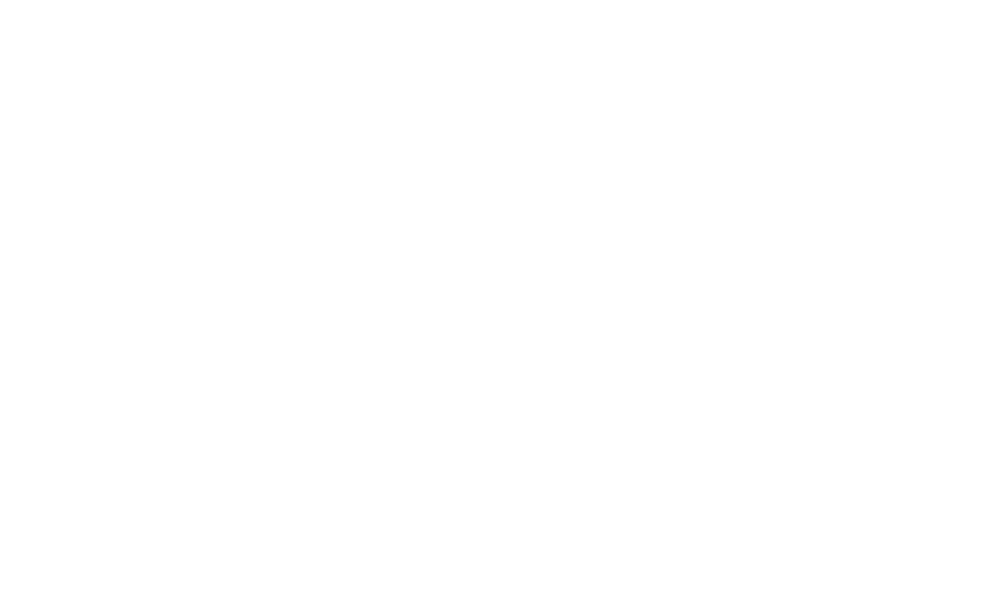

In [49]:
plt.figure(figsize=(10,6))
plt.plot(parAnumber)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


Case 1
Case 2
Case 3
Case 4


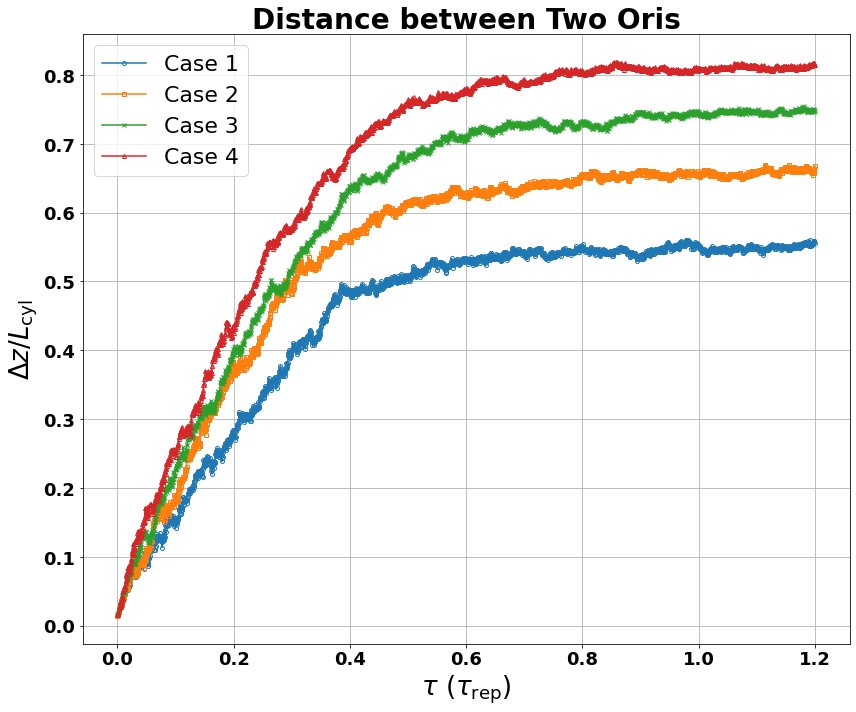

In [13]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt

L = 28
initparticle = 1000
maxiter =120
startiter =0
nframes = 2400

traj_paths = [
    "1000monruns/150ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_150_28_4_5krate_extru_old_0.8",
    "1000monruns/150ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_150_28_4_10krate_extru_old_0.8",
    "1000monruns/150ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_150_28_4_20krate_extru_old_0.8",
    
    "1000monruns/150ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_150_28_4_40krate_extru_old_0.8",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1",
    
    # '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru',
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1',
    # '1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru1',
    # '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru',
    # '1000monruns/Ringreplication/A5soft_20k_8.50_fullring_1000_70_28_4_assym_popz_extru'
]
# labels = ["70 ParA",'100 ParA', "130 ParA",'160 ParA']
# markers = ["o", "s",'^','x']

labels=['Case 1','Case 2', 'Case 3','Case 4']
markers=['o','s','x','^']

plt.figure(figsize=(12,10))

for path, lab, mark in zip(traj_paths, labels, markers):
    print(lab)
    avgdist = np.zeros(nframes)
    timefile = np.zeros(nframes)
    # if lab=='case3':
    #     startiter=30
    #     maxitter=60
    # else:
    #     startiter=60
    #     maxiter=120
    iters=np.genfromtxt(f'{path}/seginfo.txt',unpack=True)
    Niter=len(iters)
    counts=0
    for iter in range(startiter, maxiter):
    # for iter in iters:
        iter=int(iter)
        oridist = []
        data = gsd.hoomd.open(f'{path}/run_{iter}_20k_3.50_fullringrepsoft.gsd', mode='r')

        i = 0
        if len(data)==nframes:

            for frame in data:

                # if iter == startiter:
                timefile[i] = i * 50 / 100 / 1000

                R = frame.particles.N
                time = int(int(i/4) - 1)
                length = L

                if 0 <= time <= (initparticle/2):
                    k = (np.log(2*L) - np.log(L)) / (initparticle/2)
                    length = L * np.exp(k*time)
                elif time > initparticle/2:
                    length = 2*L

                if R > 1001:
                    dist = abs(frame.particles.position[0][2] -
                            frame.particles.position[1000][2]) / length
                else:
                    dist = 0

                oridist.append(dist)
                i += 1

            avgdist += np.array(oridist)
            counts=counts+1
    avgdist /= counts
    # avgdist /= len(iters)
    np.savez(f"{path}/graphdata.npz",timefile=timefile,avgdist=avgdist)
    plt.plot(timefile, avgdist, marker=mark, markersize=4,
             markerfacecolor='none', label=lab)

plt.legend(fontsize=22)
plt.title("Distance between Two Oris", fontweight='bold', fontsize=28)
plt.xlabel(r'$\tau\ (\tau_{\mathrm{rep}})$', fontsize=26, fontweight='bold')
plt.ylabel(r'$\Delta z / L_{\mathrm{cyl}}$', fontsize=26, fontweight='bold')
plt.tick_params(axis='both', labelsize=18)

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.show()

        



In [ ]:
# maxiter=30
# startiter=1
L=28
initparticle=1000
avgdist_1=np.zeros(2400)
avgori_1=np.zeros(2400)
avgori_2=np.zeros(2400)
timefile2=np.zeros(2400)
numiter=[0,4,5,6,7,8,9,10,11,13,14,17,20,21,23,26,29]
for iter in range(startiter,maxiter):
# for iter in numiter:
    ori1=[]
    ori2=[]
    oridist=[]
    data=gsd.hoomd.open(f'1000monruns/70ParA/A5soft_20k_8.50_fullring_1000_70_28_4_assym_popz_extru/run_{iter}_20k_3.50_fullringrepsoft.gsd',mode='r')
    i=0
    for frame in data:
        
        # print(ori1)
        if iter==startiter:
            timefile2[i]=i*50/100/1000
            # print(i)
        R=frame.particles.N
        time=int(int(i/4)-1)
        lenth=L
        if time>=0 and time<=(initparticle/2):
            k = (np.log(2*L) - np.log(L)) / (initparticle/2)
            lenth=L*np.exp(k*time)
        if time>initparticle/2:
            lenth=2*L
        ori1.append(frame.particles.position[0][2])
        # lenth=L
        if R>1001:
            ori2.append(frame.particles.position[1000][2])
            oridist.append((frame.particles.position[0][2]-frame.particles.position[1000][2])/lenth)
        else:
            ori2.append(frame.particles.position[0][2])
            oridist.append(0)
        i=i+1
    avgdist_1=avgdist_1+np.array(oridist)
    avgori_1=avgori_1+np.array(ori1)
    avgori_2=avgori_2+np.array(ori2)
    print(iter)
    # plt.figure(figsize=(10,6))
    # # plt.plot(timefile,avgori_1,'*',label='Ori1')
    # # plt.plot(timefile,avgori_2,'+',label='Ori2')
    # plt.plot(timefile,oridist,'.-',label='Avgdist_1')
    # plt.title(f'Run:{iter}')
    # plt.vlines(x=50000,ymin=0,ymax=1,linestyles='--',label='Replication time')
    # plt.legend()
    # plt.grid(True)



        




0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


In [24]:
avgori1=avgori1/(maxiter-startiter)
avgori2=avgori2/(maxiter-startiter)
avgdist=avgdist/(maxiter-startiter)
avgori_1=avgori_1/(maxiter-startiter)
avgori_2=avgori_2/(maxiter-startiter)
avgdist_1=avgdist_1/(maxiter-startiter)
# avgori1=avgori1/len(numiter)
# avgori2=avgori2/len(numiter)
# avgdist=avgdist/len(numiter)


Text(0, 0.5, '$\\Delta _ Z\\ / \\ L_{\\mathrm{cyl}}$')

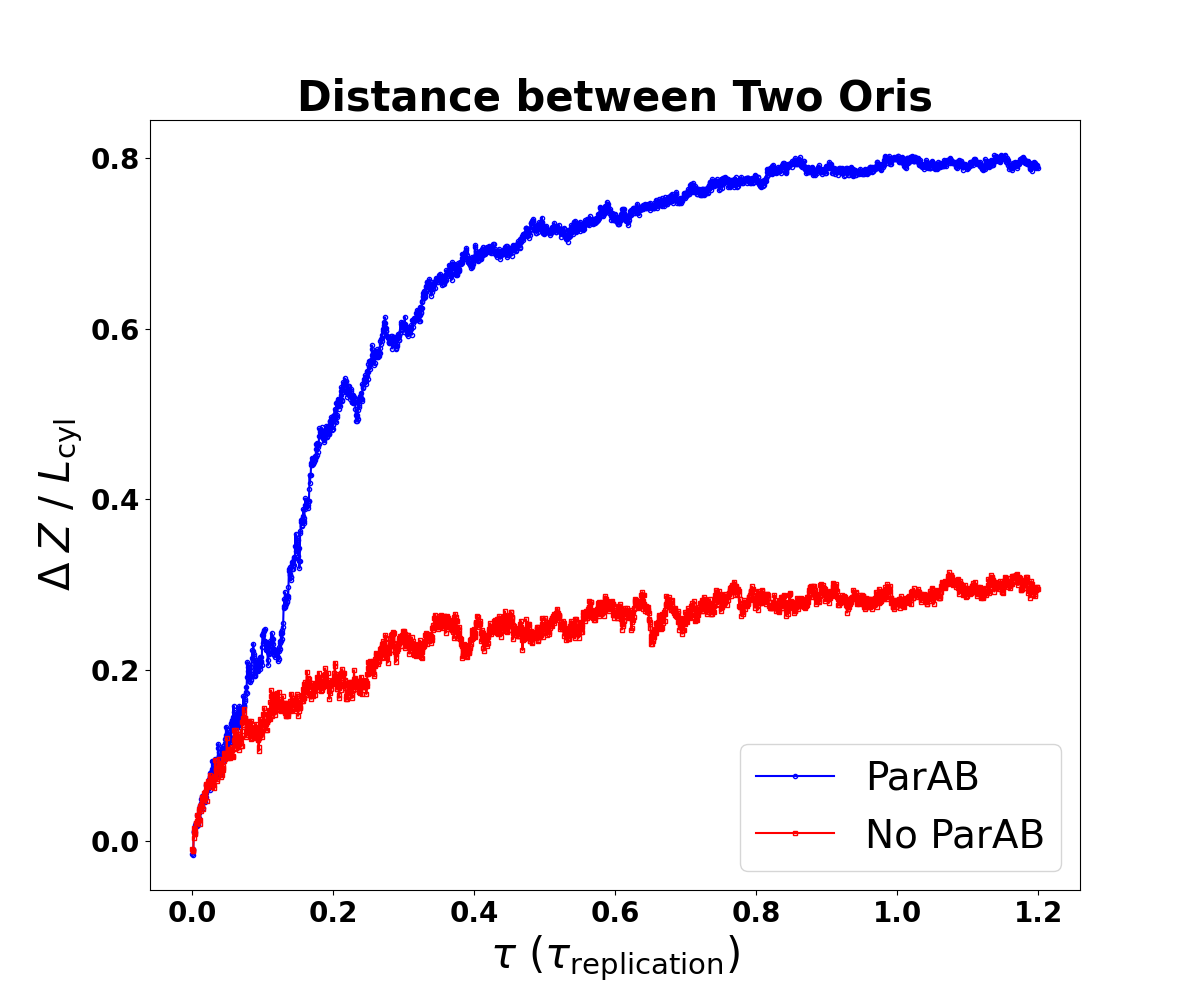

In [25]:
plt.figure(figsize=(12,10))
# plt.plot(timefile,avgori1,'*',label='Ori1')
# plt.plot(timefile,avgori2,'+',label='Ori2')
plt.plot(timefile1,avgdist,label='ParAB',markersize='3',marker='o',markerfacecolor='none',color='blue')
plt.plot(timefile2,avgdist_1,label='No ParAB',markersize='3',marker='s',markerfacecolor='none',color='red')
# plt.yscale('log')

plt.legend(fontsize=28)
plt.title(f'Distance between Two Oris',fontweight='bold',fontsize=30)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold') 
for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold') 
plt.xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$', fontsize=30, fontweight='bold')
plt.ylabel(r'$\Delta _ Z\ / \ L_{\mathrm{cyl}}$', fontsize=30, fontweight='bold')



# plt.grid(True)
# plt.savefig('Ori_dist_Ccrescentus_1000.eps',dpi=400)

In [4]:
maxiter=120
startiter=0
L=28
initparticle=1000
avgdist=np.zeros(2400)
avgori1=np.zeros(2400)
avgori2=np.zeros(2400)
timefile1=np.zeros(2400)
numiter=[20]
for iter in range(startiter,maxiter):
# for iter in numiter:
    ori1=[]
    ori2=[]
    oridist=[]
    data=gsd.hoomd.open(f'1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru/run_{iter}_20k_3.50_fullringrepsoft.gsd',mode='r')
    i=0
    for frame in data[:]:
        
        # print(ori1)
        if iter==startiter:
        # if iter==20:
            timefile1[i]=i*50/100/1000
            # print(i)
        R=frame.particles.N
        time=int(int(i/4)-1)
        lenth=L
        if time>=0 and time<=(initparticle/2):
            k = (np.log(2*L) - np.log(L)) / (initparticle/2)
            lenth=L*np.exp(k*time)
        if time>initparticle/2:
            lenth=2*L
        ori1.append(frame.particles.position[0][2])
        # lenth=L
        if R>1001:
            ori2.append(frame.particles.position[1000][2])
            oridist.append((frame.particles.position[0][2]-frame.particles.position[1000][2])/lenth)
        else:
            ori2.append(frame.particles.position[0][2])
            oridist.append(0)
        i=i+1
    avgdist=avgdist+np.array(oridist)
    avgori1=avgori1+np.array(ori1)
    avgori2=avgori2+np.array(ori2)
    print(iter)
    # plt.figure(figsize=(10,6))
    # # plt.plot(timefile,avgori1,'*',label='Ori1')
    # # plt.plot(timefile,avgori2,'+',label='Ori2')
    # plt.plot(timefile,oridist,'.-',label='Avgdist')
    # plt.title(f'Run:{iter}')
    # plt.vlines(x=50000,ymin=0,ymax=1,linestyles='--',label='Replication time')
    # plt.legend()
    # plt.grid(True)

avgori1=avgori1/(maxiter-startiter)
avgori2=avgori2/(maxiter-startiter)
avgdist=avgdist/(maxiter-startiter)

        



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119


In [5]:
maxiter=120
startiter=0
L=28
initparticle=1000
avgdist_1=np.zeros(2400)
avgori_1=np.zeros(2400)
avgori_2=np.zeros(2400)
timefile2=np.zeros(2400)
numiter=[0,4,5,6,7,8,9,10,11,13,14,17,20,21,23,26,29]
for iter in range(startiter,maxiter):
# for iter in numiter:
    ori1=[]
    ori2=[]
    oridist=[]
    data=gsd.hoomd.open(f'1000monruns/70ParA/A5soft_20k_8.50_fullring_1000_70_28_4_assym_popz_extru/run_{iter}_20k_3.50_fullringrepsoft.gsd',mode='r')
    i=0
    for frame in data:
        
        # print(ori1)
        if iter==startiter:
            timefile2[i]=i*50/100/1000
            # print(i)
        R=frame.particles.N
        time=int(int(i/4)-1)
        lenth=L
        if time>=0 and time<=(initparticle/2):
            k = (np.log(2*L) - np.log(L)) / (initparticle/2)
            lenth=L*np.exp(k*time)
        if time>initparticle/2:
            lenth=2*L
        ori1.append(frame.particles.position[0][2])
        # lenth=L
        if R>1001:
            ori2.append(frame.particles.position[1000][2])
            oridist.append((frame.particles.position[0][2]-frame.particles.position[1000][2])/lenth)
        else:
            ori2.append(frame.particles.position[0][2])
            oridist.append(0)
        i=i+1
    avgdist_1=avgdist_1+np.array(oridist)
    avgori_1=avgori_1+np.array(ori1)
    avgori_2=avgori_2+np.array(ori2)
    print(iter)
    # plt.figure(figsize=(10,6))
    # # plt.plot(timefile,avgori_1,'*',label='Ori1')
    # # plt.plot(timefile,avgori_2,'+',label='Ori2')
    # plt.plot(timefile,oridist,'.-',label='Avgdist_1')
    # plt.title(f'Run:{iter}')
    # plt.vlines(x=50000,ymin=0,ymax=1,linestyles='--',label='Replication time')
    # plt.legend()
    # plt.grid(True)


avgori_1=avgori_1/(maxiter-startiter)
avgori_2=avgori_2/(maxiter-startiter)
avgdist_1=avgdist_1/(maxiter-startiter)
        




0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


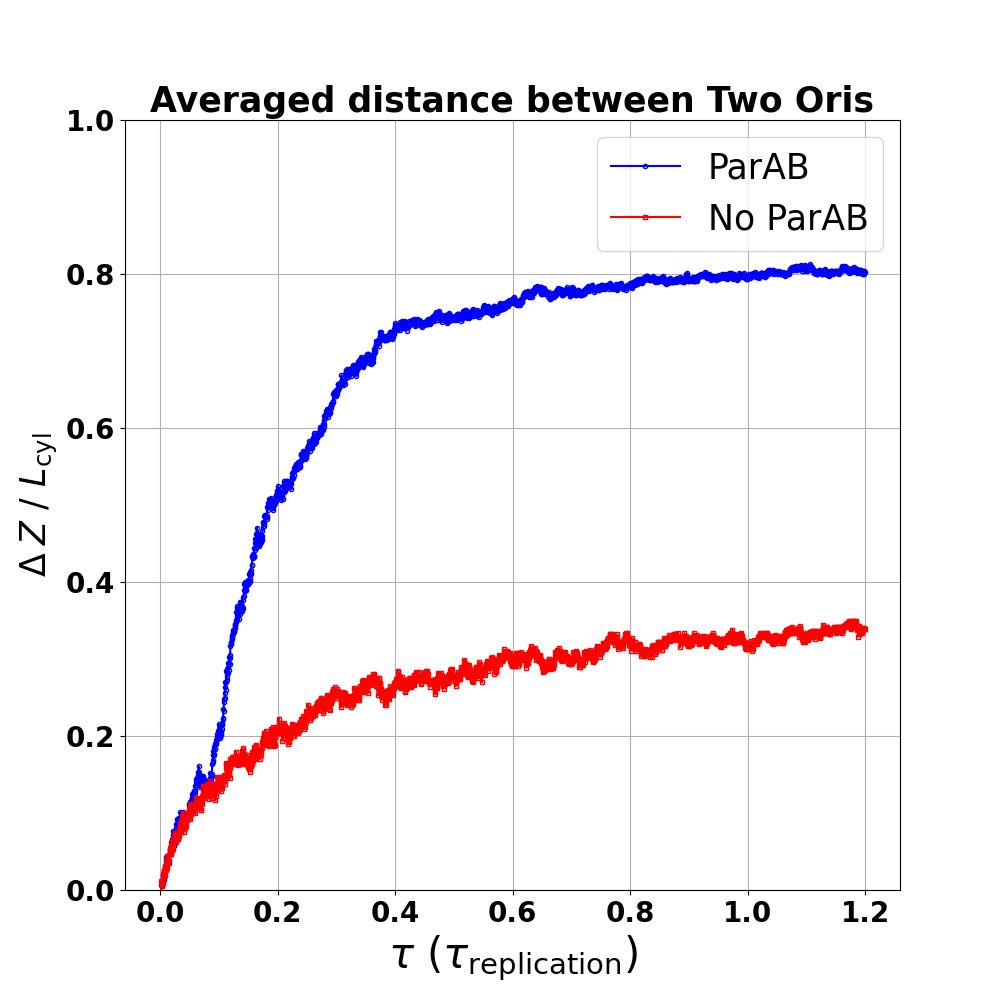

In [6]:
plt.figure(figsize=(10,10))
# plt.plot(timefile,avgori1,'*',label='Ori1')
# plt.plot(timefile,avgori2,'+',label='Ori2')
plt.plot(timefile1,avgdist,label='ParAB',markersize='3',marker='o',markerfacecolor='none',color='blue')
plt.plot(timefile2,avgdist_1,label='No ParAB',markersize='3',marker='s',markerfacecolor='none',color='red')
# plt.yscale('log')

plt.legend(fontsize=25)
plt.title(f'Averaged distance between Two Oris',fontweight='bold',fontsize=25)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold') 
for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold') 
plt.xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$', fontsize=30, fontweight='bold')
plt.ylim((0,1))
plt.ylabel(r'$\Delta _ Z\ / \ L_{\mathrm{cyl}}$', fontsize=25, fontweight='bold')



plt.grid(True)
plt.savefig('Ori_dist_Ccrescentus_1000.eps',dpi=400)

100 grad ParA
mean passage time for 100 grad ParA = 0.416
100 uniform ParA
mean passage time for 100 uniform ParA = 0.223


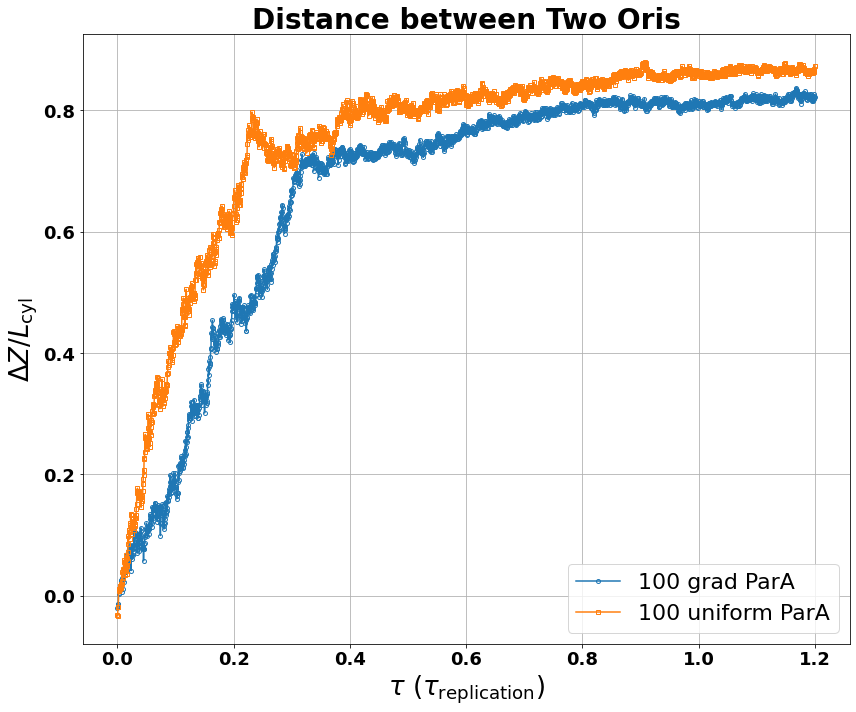

In [1]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt

L = 28
initparticle = 1000
maxiter = 30
startiter = 0
nframes = 2400

traj_paths = [
    # "1000monruns/70ParA/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru",
    # "1000monruns/99ParA/A5soft_20k_8.50_fullring_1000_99_28_4_10krate_assym_popz_extru",
    # "1000monruns/129ParA/A5soft_20k_8.50_fullring_1000_129_28_4_10krate_assym_popz_extru",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru",
    # "1000monruns/182ParA/A5soft_20k_8.50_fullring_1000_182_28_4_10krate_assym_popz_extru",
    '1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru',
    '1000monruns/100ParA/Uniform/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru2'
    
]

labels = ["100 grad ParA", "100 uniform ParA"]
markers = ["o", "s"]#,'*','+','v']

plt.figure(figsize=(12,10))
passsagetime=np.zeros((7,(maxiter-startiter)))
case=0
for path, lab, mark in zip(traj_paths, labels, markers):
    
    print(lab)
    avgdist = np.zeros(nframes)
    timefile = np.zeros(nframes)
    
    for iter in range(startiter, maxiter):
        j=0
        oridist = []
        data = gsd.hoomd.open(f'{path}/run_{iter}_20k_3.50_fullringrepsoft.gsd', mode='r')
        checkflag=True
        i = 0
        for frame in data:

            if iter == startiter:
                timefile[i] = i * 50 / 100 / 1000

            R = frame.particles.N
            time = int(int(i/4) - 1)
            length = L
            pospopz=frame.particles.position[(R-1)][2]

            
            if 0 <= time <= (initparticle/2):
                k = (np.log(2*L) - np.log(L)) / (initparticle/2)
                length = L * np.exp(k*time)
            elif time > initparticle/2:
                length = 2*L

            if R > 1001:
                dist = (frame.particles.position[0][2] -
                        frame.particles.position[1000][2]) / length
                posori=frame.particles.position[1000][2]
            else:
                dist = 0

            oridist.append(dist)
            
            checkdist=abs(pospopz-posori)
            if checkflag==True and checkdist<1.5:
                passsagetime[case][j]= timefile[i]
                checkflag=False
            
            i += 1
        
        j=j+1    
           
        avgdist += np.array(oridist)
    
    avgdist /= (maxiter - startiter)
    print( f'mean passage time for {lab} = {np.mean(passsagetime[case][passsagetime[case] != 0])}')
    case +=1 
    plt.plot(timefile, avgdist, marker=mark, markersize=4,
             markerfacecolor='none', label=lab)

plt.legend(fontsize=22)
plt.title("Distance between Two Oris", fontweight='bold', fontsize=28)
plt.xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$', fontsize=26, fontweight='bold')
plt.ylabel(r'$\Delta Z / L_{\mathrm{cyl}}$', fontsize=26, fontweight='bold')
plt.tick_params(axis='both', labelsize=18)

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.show()



Case 1


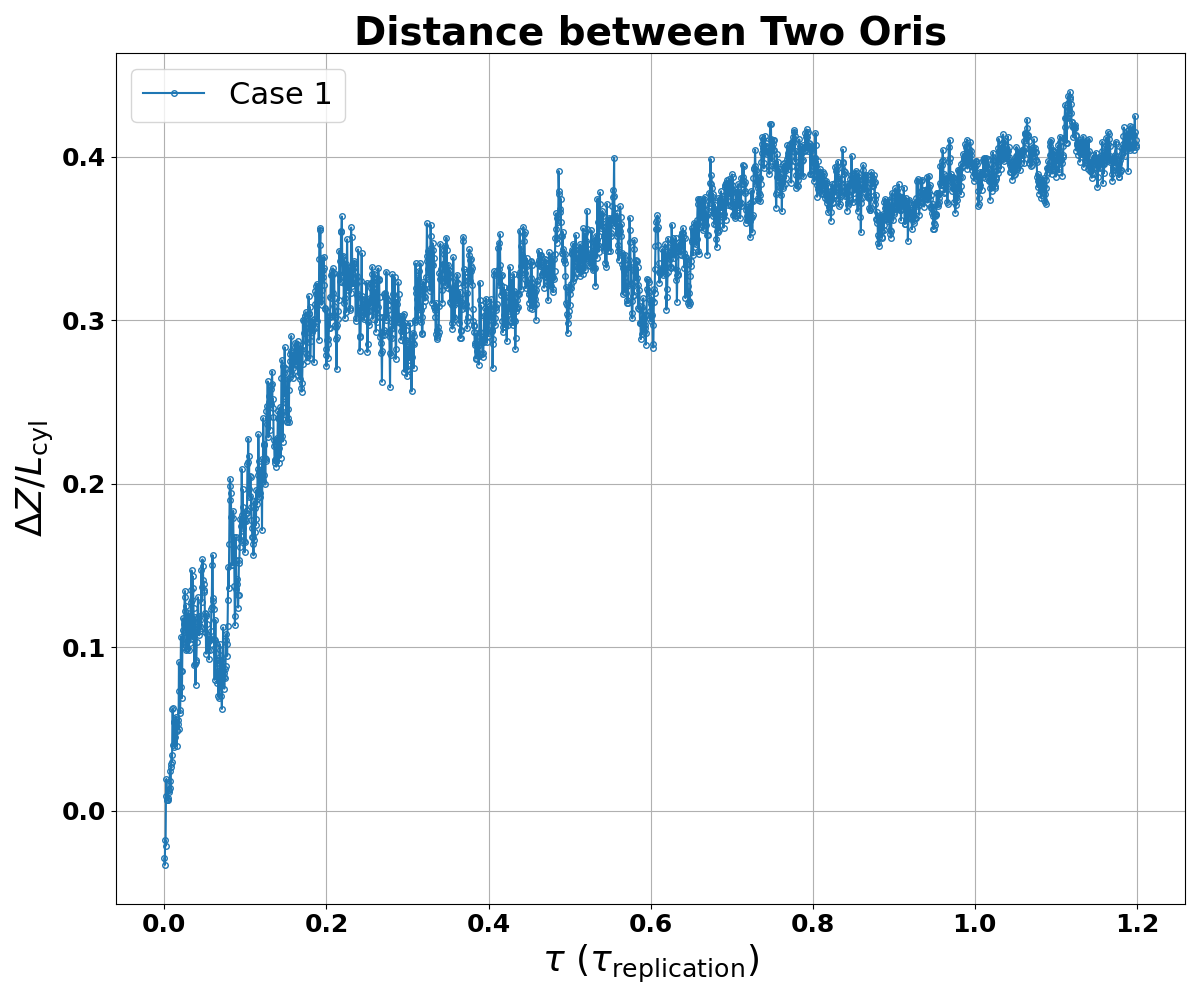

In [8]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt

L = 28
initparticle = 1000
maxiter = 20
startiter = 0
nframes = 2400

traj_paths = [
    "1000monruns/129ParA/A5soft_20k_8.50_fullring_1000_129_28_4_assym_popz_extru"
]

labels = ["Case 1"]
markers = ["o"]

plt.figure(figsize=(12,10))

for path, lab, mark in zip(traj_paths, labels, markers):
    print(lab)
    avgdist = np.zeros(nframes)
    timefile = np.zeros(nframes)

    for iter in range(startiter, maxiter):

        oridist = []
        data = gsd.hoomd.open(f'{path}/run_{iter}_20k_3.50_fullringrepsoft.gsd', mode='r')

        i = 0
        for frame in data:

            if iter == startiter:
                timefile[i] = i * 50 / 100 / 1000

            R = frame.particles.N
            time = int(int(i/4) - 1)
            length = L

            if 0 <= time <= (initparticle/2):
                k = (np.log(2*L) - np.log(L)) / (initparticle/2)
                length = L * np.exp(k*time)
            elif time > initparticle/2:
                length = 2*L

            if R > 1001:
                dist = (frame.particles.position[0][2] -
                        frame.particles.position[1000][2]) / length
            else:
                dist = 0

            oridist.append(dist)
            i += 1

        avgdist += np.array(oridist)

    avgdist /= (maxiter - startiter)

    plt.plot(timefile, avgdist, marker=mark, markersize=4,
             markerfacecolor='none', label=lab)

plt.legend(fontsize=22)
plt.title("Distance between Two Oris", fontweight='bold', fontsize=28)
plt.xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$', fontsize=26, fontweight='bold')
plt.ylabel(r'$\Delta Z / L_{\mathrm{cyl}}$', fontsize=26, fontweight='bold')
plt.tick_params(axis='both', labelsize=18)

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.show()

70 ParA
100 ParA
130 ParA
160 ParA


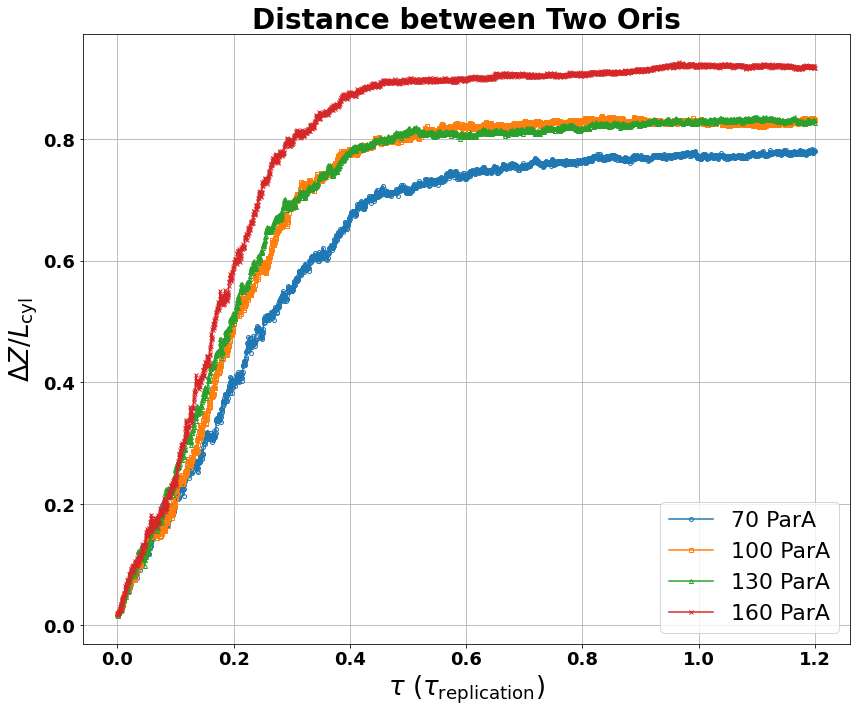

In [ ]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt

L = 28
initparticle = 1000
maxiter = 120
startiter =0
nframes = 2400

traj_paths = [
    # "1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru",
    # "1000monruns/70ParA/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru",
    
    "1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1",
    # '1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru'
    # '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru',
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru',
    # '1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru2',
    # '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru',
    # '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru'
]

labels = ["70 ParA",'100 ParA', "130 ParA",'160 ParA']
# markers = ["o", "s",'^','x']

# labels=['Case 1','Case 2','case 3','Case 4']
markers=['o','s','^','x']

plt.figure(figsize=(12,10))

for path, lab, mark in zip(traj_paths, labels, markers):
    print(lab)
    avgdist = np.zeros(nframes)
    timefile = np.zeros(nframes)
    # if lab=='Case 1':
    #     startiter=0
    #     maxitter=60
    # else:
    #     startiter=60
    #     maxiter=120

    for iter in range(startiter, maxiter):

        oridist = []
        data = gsd.hoomd.open(f'{path}/run_{iter}_20k_3.50_fullringrepsoft.gsd', mode='r')

        i = 0
        for frame in data:

            if iter == startiter:
                timefile[i] = i * 50 / 100 / 1000

            R = frame.particles.N
            time = int(int(i/4) - 1)
            length = L

            if 0 <= time <= (initparticle/2):
                k = (np.log(2*L) - np.log(L)) / (initparticle/2)
                length = L * np.exp(k*time)
            elif time > initparticle/2:
                length = 2*L

            if R > 1001:
                dist = abs(frame.particles.position[0][2] -
                        frame.particles.position[1000][2]) / length
            else:
                dist = 0

            oridist.append(dist)
            i += 1

        avgdist += np.array(oridist)

    avgdist /= (maxiter - startiter)

    plt.plot(timefile, avgdist, marker=mark, markersize=4,
             markerfacecolor='none', label=lab)

plt.legend(fontsize=22)
plt.title("Distance between Two Oris", fontweight='bold', fontsize=28)
plt.xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$', fontsize=26, fontweight='bold')
plt.ylabel(r'$\Delta Z / L_{\mathrm{cyl}}$', fontsize=26, fontweight='bold')
plt.tick_params(axis='both', labelsize=18)

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.show()



<function matplotlib.pyplot.show(block=None)>

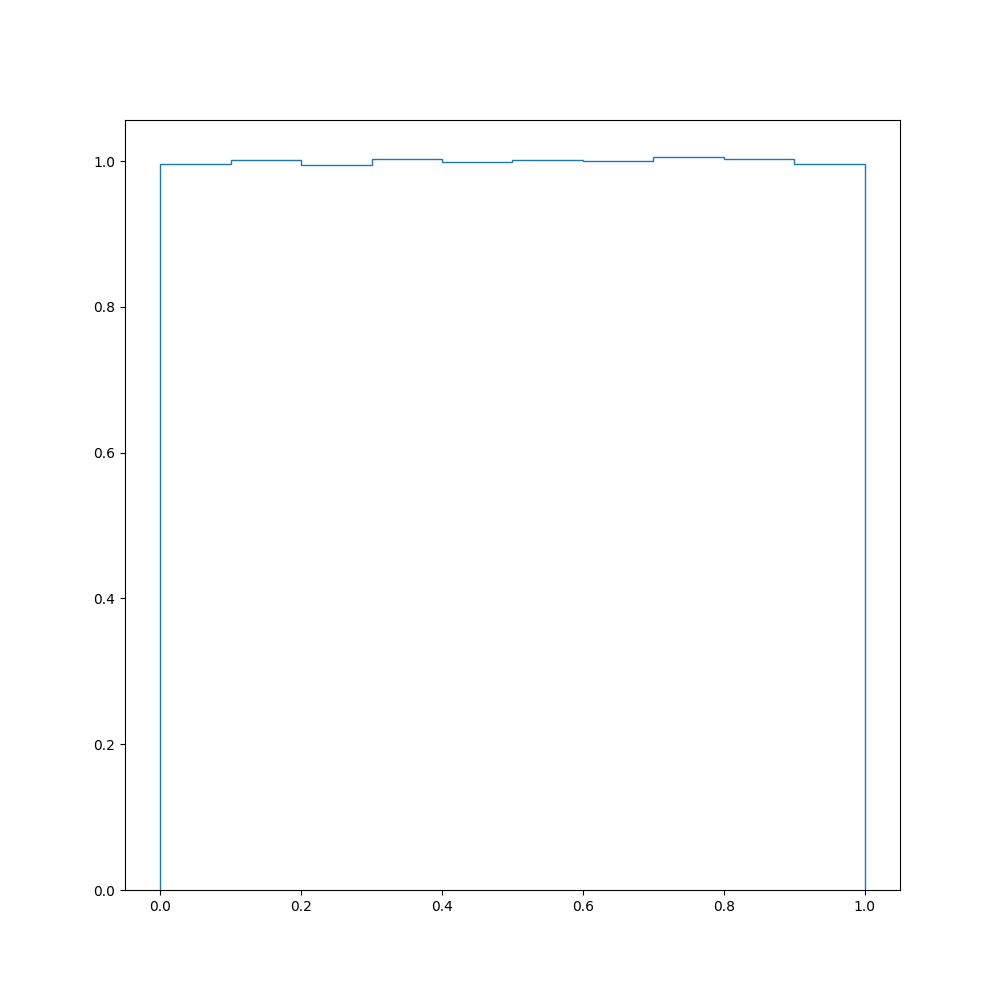

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


Case 1
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
Case 2
120


FileNotFoundError: [Errno 2] No such file or directory: '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru2/run_120_20k_3.50_fullringrepsoft.gsd'

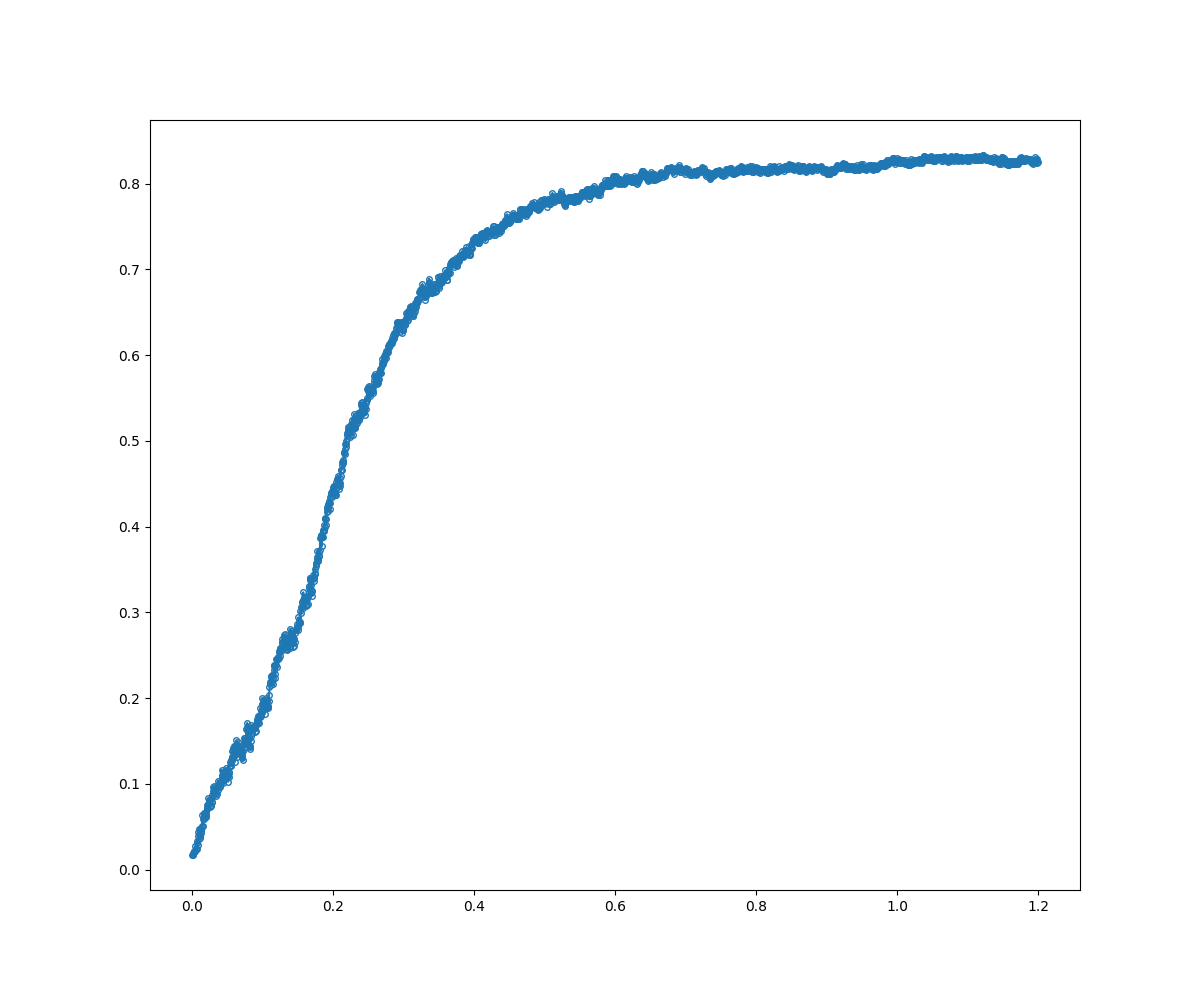

In [47]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt

L = 28
initparticle = 1000
maxiter = 120
startiter =0
nframes = 2400

traj_paths = [
    # "1000monruns/140ParA/A5soft_20k_8.50_fullring_1000_140_28_4_10krate_assym_popz_extru1",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1",
    # "1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru",
    
    # "1000monruns/129ParA/A5soft_20k_8.50_fullring_1000_129_28_4_10krate_assym_popz_extru1",
    # "1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1",
    # '1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru',
    #  '1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru',
    # '1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru1',
    # '1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru2',
    # '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru',
    # '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1',
    # '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru2',
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru',
    '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru2',
    '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru2',
    # '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru',
    # '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1',
    # '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1'
]

# labels = ["160 ParA",'100 ParA', "160 ParA",'100 ParA']
# markers = ["o", "s",'^','x']

labels=['Case 1','Case 2']
markers=['o','s']

plt.figure(figsize=(12,10))

for path, lab, mark in zip(traj_paths, labels, markers):
    print(lab)
    avgdist = np.zeros(nframes)
    timefile = np.zeros(nframes)
    if lab=='Case 1':
        startiter=120
        maxiter=240
    # else:
    #     startiter=60
    #     maxiter=120

    for iter in range(startiter, maxiter):
        print(f'{iter}')
        oridist = []
        data = gsd.hoomd.open(f'{path}/run_{iter}_20k_3.50_fullringrepsoft.gsd', mode='r')

        i = 0
        for frame in data[:2400]:

            if iter == startiter:
                timefile[i] = i * 50 / 100 / 1000

            R = frame.particles.N
            time = int(int(i/4) - 1)
            length = L

            if 0 <= time <= (initparticle/2):
                k = (np.log(2*L) - np.log(L)) / (initparticle/2)
                length = L * np.exp(k*time)
            elif time > initparticle/2:
                length = 2*L

            if R > 1001:
                dist = abs(frame.particles.position[0][2] -
                        frame.particles.position[1000][2]) / length
            else:
                dist = 0

            oridist.append(dist)
            i += 1

        avgdist += np.array(oridist)

    avgdist /= (maxiter - startiter)

    plt.plot(timefile, avgdist, marker=mark, markersize=4,
             markerfacecolor='none', label=lab)

plt.legend(fontsize=22)
plt.title("Distance between Two Oris", fontweight='bold', fontsize=28)
plt.xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$', fontsize=26, fontweight='bold')
plt.ylabel(r'$\Delta Z / L_{\mathrm{cyl}}$', fontsize=26, fontweight='bold')
plt.tick_params(axis='both', labelsize=18)

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.show()


70 ParA
100 ParA
130 ParA
160 ParA


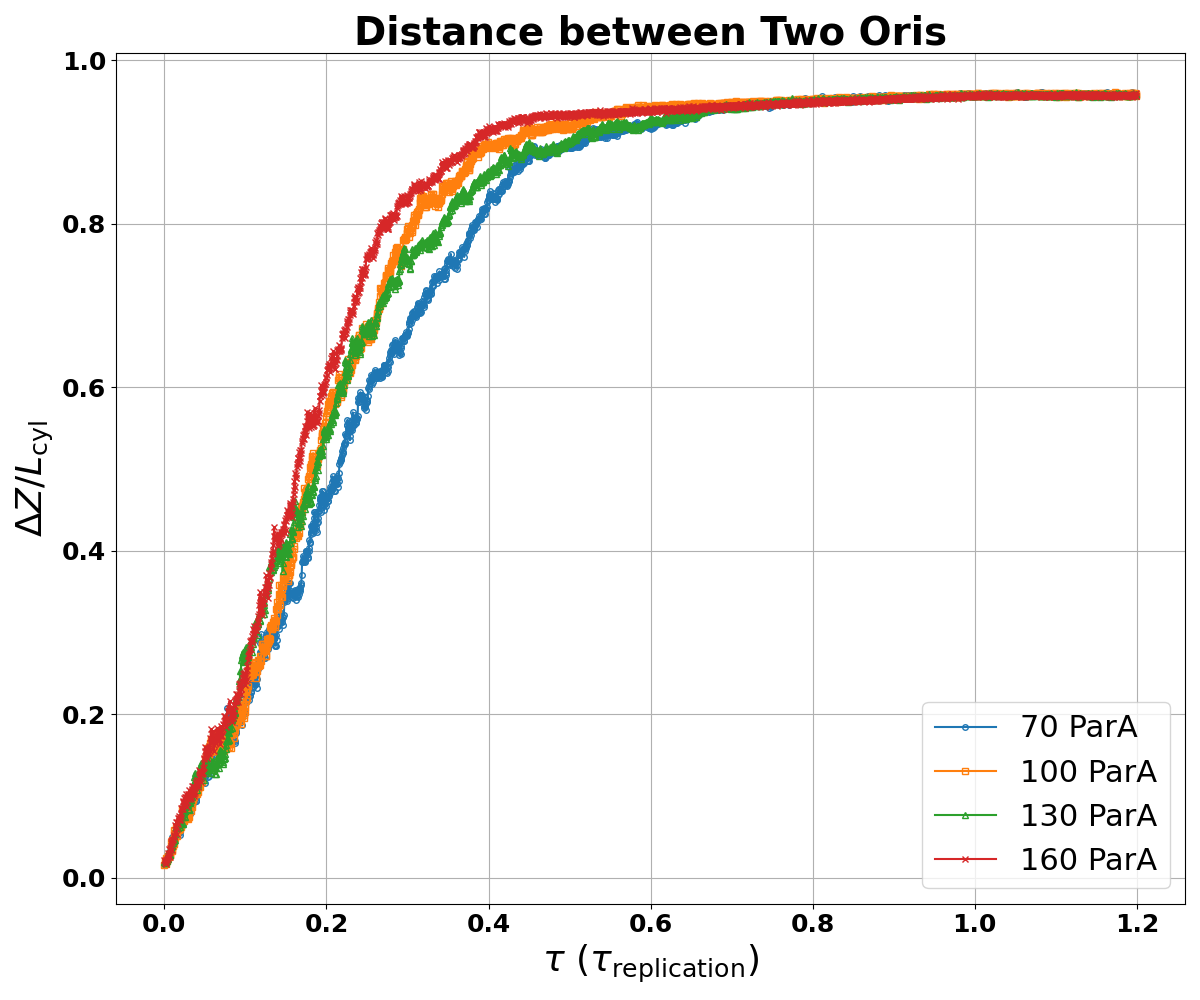

In [24]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt

L = 28
initparticle = 1000
maxiter =120
startiter =0
nframes = 2400

traj_paths = [
    "1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru",
    "1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru",
    "1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru",
    
    "1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1",
    
    # '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru',
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1',
    # '1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru1',
    # '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru',
    # '1000monruns/Ringreplication/A5soft_20k_8.50_fullring_1000_70_28_4_assym_popz_extru'
]
labels = ["70 ParA",'100 ParA', "130 ParA",'160 ParA']
markers = ["o", "s",'^','x']

# labels=['Case 1','Case 2']
# markers=['o','s']

plt.figure(figsize=(12,10))

for path, lab, mark in zip(traj_paths, labels, markers):
    print(lab)
    avgdist = np.zeros(nframes)
    timefile = np.zeros(nframes)
    if lab=='case3':
        startiter=30
        maxitter=60
    # else:
    #     startiter=60
    #     maxiter=120
    iters=np.genfromtxt(f'{path}/seginfo.txt',unpack=True)
    Niter=len(iters)
    # for iter in range(startiter, maxiter):
    for iter in iters:
        iter=int(iter)
        oridist = []
        data = gsd.hoomd.open(f'{path}/run_{iter}_20k_3.50_fullringrepsoft.gsd', mode='r')

        i = 0
        for frame in data:

            # if iter == startiter:
            timefile[i] = i * 50 / 100 / 1000

            R = frame.particles.N
            time = int(int(i/4) - 1)
            length = L

            if 0 <= time <= (initparticle/2):
                k = (np.log(2*L) - np.log(L)) / (initparticle/2)
                length = L * np.exp(k*time)
            elif time > initparticle/2:
                length = 2*L

            if R > 1001:
                dist = abs(frame.particles.position[0][2] -
                        frame.particles.position[1000][2]) / length
            else:
                dist = 0

            oridist.append(dist)
            i += 1

        avgdist += np.array(oridist)

    # avgdist /= (maxiter - startiter)
    avgdist /= len(iters)

    plt.plot(timefile, avgdist, marker=mark, markersize=4,
             markerfacecolor='none', label=lab)

plt.legend(fontsize=22)
plt.title("Distance between Two Oris", fontweight='bold', fontsize=28)
plt.xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$', fontsize=26, fontweight='bold')
plt.ylabel(r'$\Delta Z / L_{\mathrm{cyl}}$', fontsize=26, fontweight='bold')
plt.tick_params(axis='both', labelsize=18)

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
import gsd.hoomd
import numpy as np
import matplotlib.pyplot as plt
file= gsd.hoomd.open('1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru/run_30_20k_3.50_fullringrepsoft.gsd','r')

In [13]:
sums=np.zeros(200)
i=0
len(file)
for frames in file:

    ids=frames.particles.typeid
    sums[i]=np.sum(ids==3)
    # print(sum)
    i=i+1

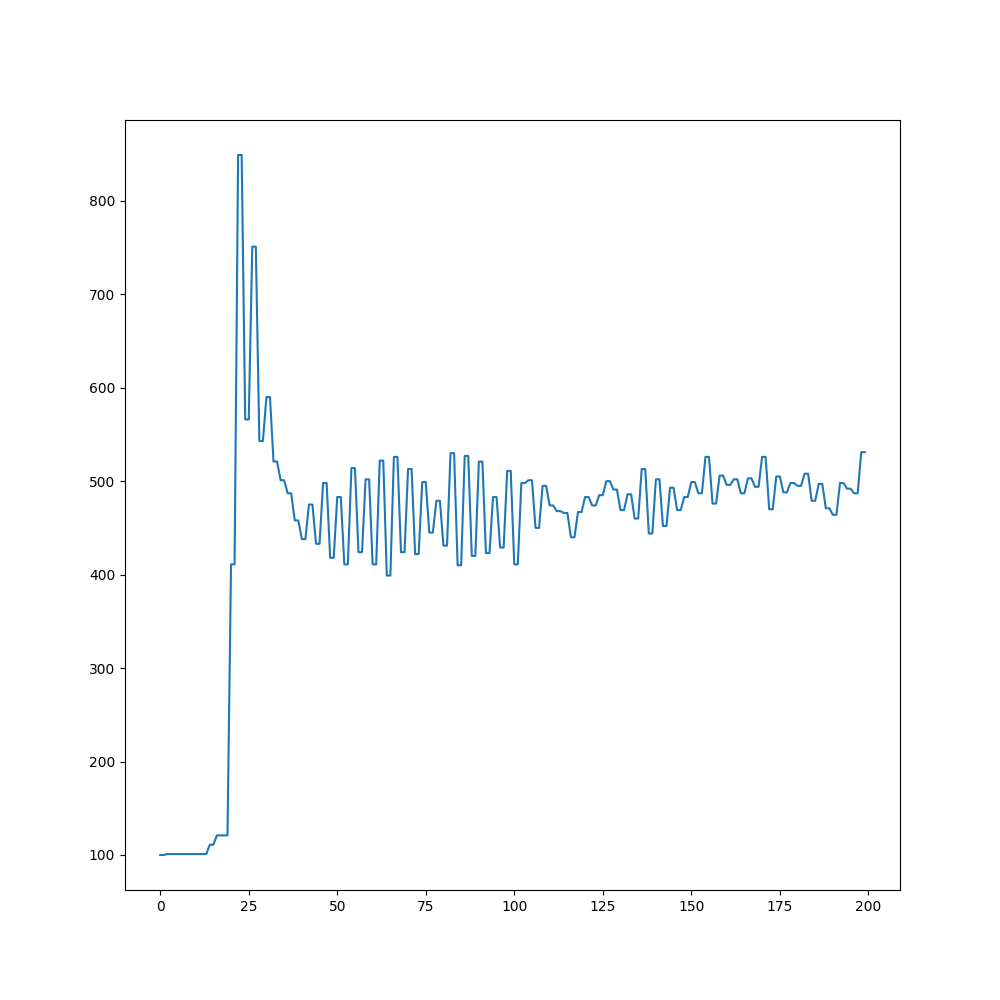

In [14]:
%matplotlib widget
plt.figure(figsize=(10,10))
plt.plot(sums)
plt.show()

Case 1
Case 2
Case 3
Case 4


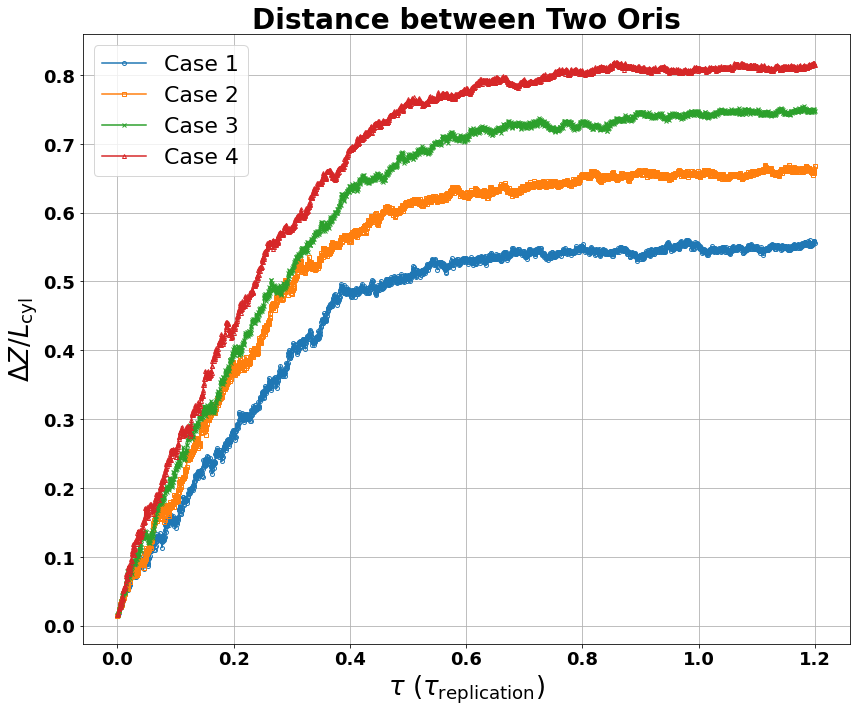

In [ ]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt

L = 28
initparticle = 1000
maxiter =120
startiter =0
nframes = 2400

traj_paths = [
    "1000monruns/150ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_150_28_4_5krate_extru_old_0.8",
    "1000monruns/150ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_150_28_4_10krate_extru_old_0.8",
    "1000monruns/150ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_150_28_4_20krate_extru_old_0.8",
    
    "1000monruns/150ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_150_28_4_40krate_extru_old_0.8",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1",
    
    # '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru',
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1',
    # '1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru1',
    # '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru',
    # '1000monruns/Ringreplication/A5soft_20k_8.50_fullring_1000_70_28_4_assym_popz_extru'
]
# labels = ["70 ParA",'100 ParA', "130 ParA",'160 ParA']
# markers = ["o", "s",'^','x']

labels=['Case 1','Case 2', 'Case 3','Case 4']
markers=['o','s','x','^']

plt.figure(figsize=(12,10))

for path, lab, mark in zip(traj_paths, labels, markers):
    print(lab)
    avgdist = np.zeros(nframes)
    timefile = np.zeros(nframes)
    # if lab=='case3':
    #     startiter=30
    #     maxitter=60
    # else:
    #     startiter=60
    #     maxiter=120
    iters=np.genfromtxt(f'{path}/seginfo.txt',unpack=True)
    Niter=len(iters)
    counts=0
    for iter in range(startiter, maxiter):
    # for iter in iters:
        iter=int(iter)
        oridist = []
        data = gsd.hoomd.open(f'{path}/run_{iter}_20k_3.50_fullringrepsoft.gsd', mode='r')

        i = 0

        for frame in data:

            # if iter == startiter:
            timefile[i] = i * 50 / 100 / 1000

            R = frame.particles.N
            time = int(int(i/4) - 1)
            length = L

            if 0 <= time <= (initparticle/2):
                k = (np.log(2*L) - np.log(L)) / (initparticle/2)
                length = L * np.exp(k*time)
            elif time > initparticle/2:
                length = 2*L

            if R > 1001:
                dist = abs(frame.particles.position[0][2] -
                        frame.particles.position[1000][2]) / length
            else:
                dist = 0

            oridist.append(dist)
            i += 1

        avgdist += np.array(oridist)
        counts=counts+1
    avgdist /= counts
    # avgdist /= len(iters)

    plt.plot(timefile, avgdist, marker=mark, markersize=4,
             markerfacecolor='none', label=lab)

plt.legend(fontsize=22)
plt.title("Distance between Two Oris", fontweight='bold', fontsize=28)
plt.xlabel(r'$\tau\ (\tau_{\mathrm{rep}})$', fontsize=26, fontweight='bold')
plt.ylabel(r'$\Delta z / L_{\mathrm{cyl}}$', fontsize=26, fontweight='bold')
plt.tick_params(axis='both', labelsize=18)

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.show()


Case 1


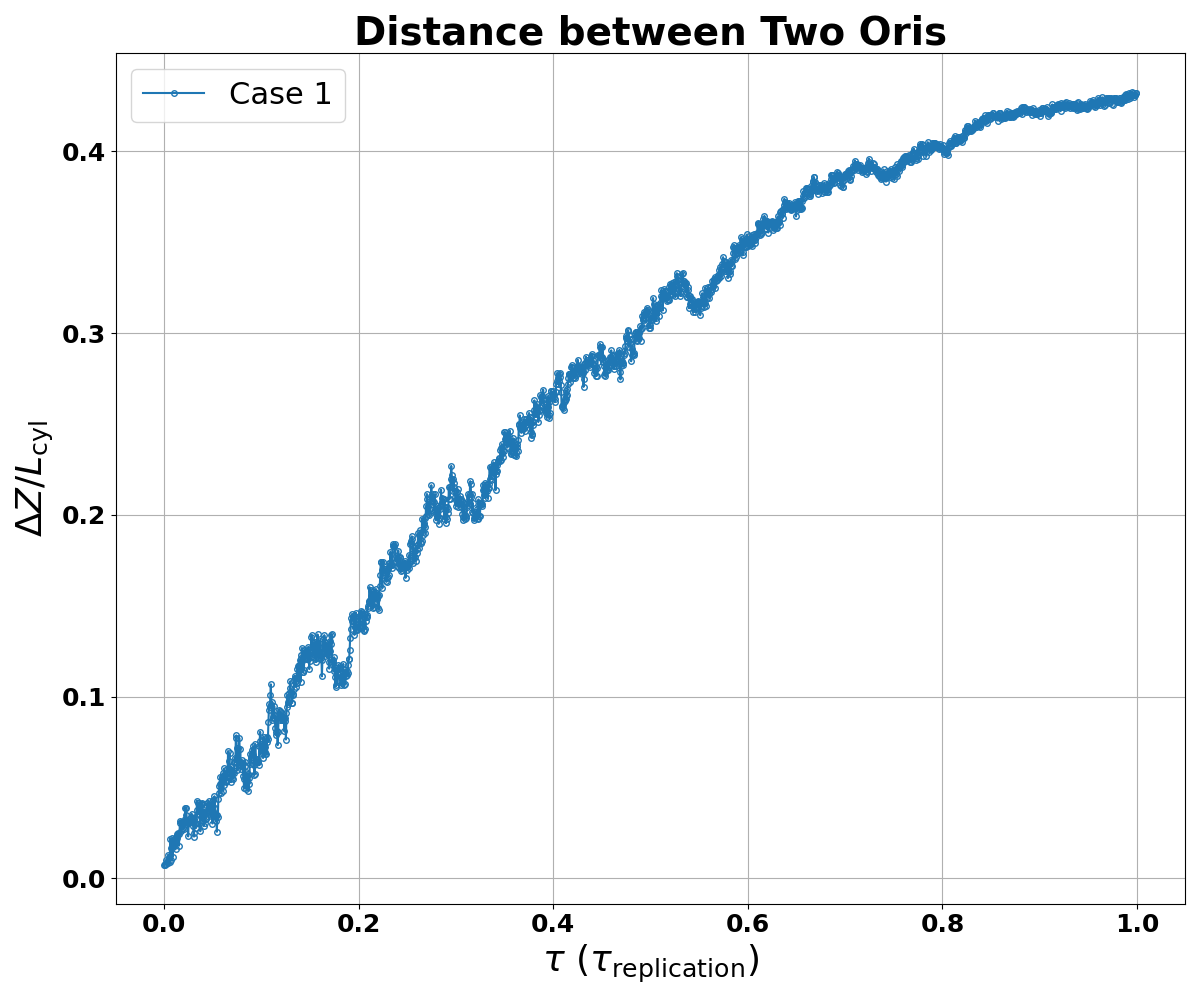

In [ ]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt

L = 28
initparticle = 1000
maxiter =60
startiter =0
nframes = 2000

traj_paths = [
    # "1000monruns/140ParA/A5soft_20k_8.50_fullring_1000_140_28_4_10krate_assym_popz_extru1",
    # "1000monruns/70ParA/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru",
    
    # "1000monruns/129ParA/A5soft_20k_8.50_fullring_1000_129_28_4_10krate_assym_popz_extru1",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1",
    # '1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru'
    # '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru',
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_ParAchange',
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru',
    #  '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1'
#     '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru',
#     '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1'
]

# labels = ["70 ParA",'100 ParA', "70 ParA",'160 ParA']
# markers = ["o", "s",'^','x']

labels=['Case 1','Case 2']
markers=['o','s']

plt.figure(figsize=(12,10))

for path, lab, mark in zip(traj_paths, labels, markers):
    print(lab)
    avgdist = np.zeros(nframes)
    timefile = np.zeros(nframes)
    if lab=='case3':
        startiter=30
        maxitter=60
    # else:
    #     startiter=60
    #     maxiter=120
    iters=np.genfromtxt(f'{path}/seginfo.txt',unpack=True)
    Niter=len(iters)
    # for iter in range(startiter, maxiter):
    for iter in iters:
        iter=int(iter)
        oridist = []
        data = gsd.hoomd.open(f'{path}/run_{iter}_20k_3.50_fullringrepsoft.gsd', mode='r')

        i = 0
        for frame in data:

            # if iter == startiter:
            timefile[i] = i * 50 / 100 / 1000

            R = frame.particles.N
            time = int(int(i/4) - 1)
            length = L

            if 0 <= time <= (initparticle/2):
                k = (np.log(2*L) - np.log(L)) / (initparticle/2)
                length = L * np.exp(k*time)
            elif time > initparticle/2:
                length = 2*L

            if R > 1001:
                dist = abs(frame.particles.position[0][2] -
                        frame.particles.position[1000][2]) / length
            else:
                dist = 0


            oridist.append(dist)
            i += 1

        avgdist += np.array(oridist)

    avgdist /= (maxiter - startiter)
    # avgdist /= len(iters)

    plt.plot(timefile, avgdist, marker=mark, markersize=4,
             markerfacecolor='none', label=lab)

plt.legend(fontsize=22)
plt.title("Distance between Two Oris", fontweight='bold', fontsize=28)
plt.xlabel(r'$\tau\ (\tau_{\mathrm{replication}})$', fontsize=26, fontweight='bold')
plt.ylabel(r'$\Delta Z / L_{\mathrm{cyl}}$', fontsize=26, fontweight='bold')
plt.tick_params(axis='both', labelsize=18)

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
import numpy as np
import gsd.hoomd
import matplotlib.pyplot as plt

L = 28
initparticle = 1000
maxiter =120
startiter =0
nframes = 2400

traj_paths = [
    # "1000monruns/140ParA/A5soft_20k_8.50_fullring_1000_140_28_4_10krate_assym_popz_extru1",
    # "1000monruns/70ParA/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru",
    
    # "1000monruns/129ParA/A5soft_20k_8.50_fullring_1000_129_28_4_10krate_assym_popz_extru1",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1",
    # '1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru'
    # '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru',
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_ParAchange',
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru',
    #  '1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru'
#     '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru',
#     '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1'
]

seginfo=open(f'{traj_paths[0]}/seginfo.txt',mode='w')


for iter in range(120):
    print(f'\r {iter}',end=' ')
    data = gsd.hoomd.open(f'{traj_paths[0]}/run_{iter}_20k_3.50_fullringrepsoft.gsd', mode='r')
    frame=data[-1]
    R = frame.particles.N
    if R > 1001:
            pospopz=frame.particles.position[(R-1)][2]
            posori=frame.particles.position[1000][2]
    checkdist=abs(pospopz-posori)
    if checkdist<1.0:
        seginfo.write(f'{iter} \n')

 61 

FileNotFoundError: [Errno 2] No such file or directory: '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru/run_61_20k_3.50_fullringrepsoft.gsd'